# ゼロから作る Deep Learning ❸ 輪読会
## 第3ステージ「高階微分を実現する」 ― ステップ 25 〜 30

### これまでの内容

第 1・第 2 ステージを通して、DeZero で以下のことができるようになった。  
- `Variable` (値 `data` と微分 `grad`) と `Function` (`forward`/`backward`) による自動微分
- 複数入出力・複雑なグラフの正しい微分 (世代の管理)、メモリの管理 (`weakref`, `no_grad`)
- 演算子オーバーロード (`y = a*b + c` のように自然に書ける)

現状の DeZero は「いつものコードを書けば、その 1 階微分 (勾配) が自動で求まる」フレームワークである。  

### 第 3 ステージの目標 ― 高階微分
第 3 ステージでは高階微分 (higher-order derivative) について学ぶ。高階微分とは、微分をさらに微分すること。たとえば 2 階微分 $f''(x)$ は「傾きの変化率」を表し、後で学ぶニュートン法という強力な最適化に使える。  

このステージ前半（25〜30）は、高階微分を実装するための導入にあたる。  

| ステップ | テーマ | 位置づけ |
|---|---|---|
| 25 | 計算グラフの可視化 (1) | 道具づくり：Graphviz と DOT言語 |
| 26 | 計算グラフの可視化 (2) | 道具づくり：DeZeroのグラフを自動描画 |
| 27 | テイラー展開の微分 | 応用：`sin` を実装し級数近似を微分 |
| 28 | 関数の最適化 | 応用：勾配降下法でローゼンブロック関数を最小化 |
| 29 | ニュートン法 (手計算) | 動機：2 階微分を使うと最適化が速い |
| 30 | 高階微分 (準備編) | 準備：問題の確認 |

ステップ 29 でニュートン法の効率を確認し、ステップ 30 で「そのために高階微分が必要」という課題を明確にする。その解決 (ステップ 31 以降) へのお膳立てが、この回の目標。  


## ライブラリ読み込み

このノートブックが単独で動くように、第 2 ステージまでの DeZero を最初にまとめて読み込む。  

内容は `Variable`/`Function`/四則演算・累乗の各関数/演算子オーバーロード (`setup_variable`) である。この上に、今回の可視化・最適化を実装する。  

In [1]:
import numpy as np
import weakref
import contextlib
import matplotlib.pyplot as plt

# ===== 第 2 ステージまでの DeZero =====
class Config:
    enable_backprop = True

@contextlib.contextmanager
def using_config(name, value):
    old_value = getattr(Config, name)
    setattr(Config, name, value)
    try:
        yield
    finally:
        setattr(Config, name, old_value)

def no_grad():
    return using_config('enable_backprop', False)

def as_array(x):
    if np.isscalar(x):
        return np.array(x)
    return x

def as_variable(obj):
    if isinstance(obj, Variable):
        return obj
    return Variable(obj)


class Variable:
    __array_priority__ = 200

    def __init__(self, data, name=None):
        if data is not None:
            if not isinstance(data, np.ndarray):
                raise TypeError('{} is not supported'.format(type(data)))
        self.data = data
        self.name = name
        self.grad = None
        self.creator = None
        self.generation = 0

    def set_creator(self, func):
        self.creator = func
        self.generation = func.generation + 1

    def cleargrad(self):
        self.grad = None

    @property
    def shape(self):
        return self.data.shape
    @property
    def ndim(self):
        return self.data.ndim
    @property
    def size(self):
        return self.data.size
    @property
    def dtype(self):
        return self.data.dtype

    def __len__(self):
        return len(self.data)

    def __repr__(self):
        if self.data is None:
            return 'variable(None)'
        p = str(self.data).replace('\n', '\n' + ' ' * 9)
        return 'variable(' + p + ')'

    def backward(self, retain_grad=False):
        if self.grad is None:
            self.grad = np.ones_like(self.data)
        funcs = []
        seen_set = set()
        def add_func(f):
            if f not in seen_set:
                funcs.append(f)
                seen_set.add(f)
                funcs.sort(key=lambda x: x.generation)
        add_func(self.creator)
        while funcs:
            f = funcs.pop()
            gys = [output().grad for output in f.outputs]
            gxs = f.backward(*gys)
            if not isinstance(gxs, tuple):
                gxs = (gxs,)
            for x, gx in zip(f.inputs, gxs):
                if x.grad is None:
                    x.grad = gx
                else:
                    x.grad = x.grad + gx
                if x.creator is not None:
                    add_func(x.creator)
            if not retain_grad:
                for y in f.outputs:
                    y().grad = None


class Function:
    def __call__(self, *inputs):
        inputs = [as_variable(x) for x in inputs]
        xs = [x.data for x in inputs]
        ys = self.forward(*xs)
        if not isinstance(ys, tuple):
            ys = (ys,)
        outputs = [Variable(as_array(y)) for y in ys]
        if Config.enable_backprop:
            self.generation = max([x.generation for x in inputs])
            for output in outputs:
                output.set_creator(self)
            self.inputs = inputs
            self.outputs = [weakref.ref(output) for output in outputs]
        return outputs if len(outputs) > 1 else outputs[0]
    def forward(self, xs):
        raise NotImplementedError()
    def backward(self, gys):
        raise NotImplementedError()


# --- 四則演算・累乗 ---
class Add(Function):
    def forward(self, x0, x1):
        return x0 + x1
    def backward(self, gy):
        return gy, gy
class Mul(Function):
    def forward(self, x0, x1):
        return x0 * x1
    def backward(self, gy):
        x0, x1 = self.inputs[0].data, self.inputs[1].data
        return gy * x1, gy * x0
class Neg(Function):
    def forward(self, x):
        return -x
    def backward(self, gy):
        return -gy
class Sub(Function):
    def forward(self, x0, x1):
        return x0 - x1
    def backward(self, gy):
        return gy, -gy
class Div(Function):
    def forward(self, x0, x1):
        return x0 / x1
    def backward(self, gy):
        x0, x1 = self.inputs[0].data, self.inputs[1].data
        return gy / x1, gy * (-x0 / x1 ** 2)
class Pow(Function):
    def __init__(self, c):
        self.c = c
    def forward(self, x):
        return x ** self.c
    def backward(self, gy):
        x = self.inputs[0].data
        c = self.c
        return c * x ** (c - 1) * gy

def add(x0, x1):
    return Add()(x0, as_array(x1))
def mul(x0, x1):
    return Mul()(x0, as_array(x1))
def neg(x):
    return Neg()(x)
def sub(x0, x1):
    return Sub()(x0, as_array(x1))
def rsub(x0, x1):
    return Sub()(as_array(x1), x0)
def div(x0, x1):
    return Div()(x0, as_array(x1))
def rdiv(x0, x1):
    return Div()(as_array(x1), x0)
def pow(x, c):
    return Pow(c)(x)

def setup_variable():
    Variable.__add__ = add
    Variable.__radd__ = add
    Variable.__mul__ = mul
    Variable.__rmul__ = mul
    Variable.__neg__ = neg
    Variable.__sub__ = sub
    Variable.__rsub__ = rsub
    Variable.__truediv__ = div
    Variable.__rtruediv__ = rdiv
    Variable.__pow__ = pow

setup_variable()


---
# ステップ 25・26：計算グラフの可視化

高階微分の実装は複雑で、計算グラフが入り組む。そこで、まず計算グラフを図として可視化する道具を用意する。これがあると、後のステップで「今どんなグラフができているか」を確認できる。  

## 25.1 Graphviz と DOT 言語

Graphviz は、グラフ (ノードと矢印) を描画する定番のツール。描きたいグラフを DOT 言語という簡単なテキストで記述すると、画像に変換してくれる。  

DOT 言語の基本はとてもシンプル。  

```dot
digraph g {
    x
    y
    x -> y      // x から y へ矢印
}
```

- `digraph g { ... }` が全体の枠 (有向グラフ)。  
- 各行にノードを書く。  
- `A -> B` でノード間に矢印を引く。  
- ノードには色や形などの属性を付けられる (例：`x [label="x", color=orange, style=filled]`)。  

DeZero では、変数をオレンジの丸、関数を水色の四角で描く。それを DOT 言語で表現する。  


## 26.2 計算グラフから DOT 言語への変換

DeZero の計算グラフは `Variable` と `Function` の `creator`/`inputs`/`outputs` のつながりで表されている。これを辿って DOT 言語の文字列を組み立てれば、自動で可視化できる。  

作る関数は次の 3 つである。  

- `_dot_var(v)`：1 つの変数を DOT の 1 行に変換 (オレンジの丸)。  
- `_dot_func(f)`：1 つの関数と、その入出力への矢印を DOT に変換 (水色の四角)。  
- `get_dot_graph(output)`：出力変数から `creator` を辿り、グラフ全体の DOT 文字列を作る。  

Graphviz 本体が入っていない環境でのこの Notebook の利用を考慮し、DOT 文字列を作るところまでを実装し、描画は後で matplotlib による自作関数で代替する。まずは DOT 生成コードを実装する。  


In [2]:
def _dot_var(v, verbose=False):
    # 変数を 1 つ、DOT 言語のノード定義に変換する
    name = '' if v.name is None else v.name
    if verbose and v.data is not None:
        if v.name is not None:
            name += ': '
        name += str(v.shape) + ' ' + str(v.dtype)
    # id(v) で各オブジェクト固有の番号を使い、ノードを一意に識別する
    return '{} [label="{}", color=orange, style=filled]\n'.format(id(v), name)


def _dot_func(f):
    # 関数を 1 つ、DOT 言語のノード定義に変換する (水色の四角)
    txt = '{} [label="{}", color=lightblue, style=filled, shape=box]\n'.format(
        id(f), f.__class__.__name__)
    # 入力変数 → 関数 の矢印
    for x in f.inputs:
        txt += '{} -> {}\n'.format(id(x), id(f))
    # 関数 → 出力変数 の矢印 (outputs は弱参照なので y() でアクセス)
    for y in f.outputs:
        txt += '{} -> {}\n'.format(id(f), id(y()))
    return txt


def get_dot_graph(output, verbose=True):
    # 出力変数から creator を辿り、計算グラフ全体を DOT 文字列にする
    txt = ''
    funcs = []
    seen_set = set()
    def add_func(f):
        if f not in seen_set:
            funcs.append(f)
            seen_set.add(f)
    add_func(output.creator)
    txt += _dot_var(output, verbose)
    while funcs:
        func = funcs.pop()
        txt += _dot_func(func)
        for x in func.inputs:
            txt += _dot_var(x, verbose)
            if x.creator is not None:
                add_func(x.creator)
    return 'digraph g {\n' + txt + '}'



試しに、$z = x^2 + y^2$ (Sphere 関数) の計算グラフを DOT 言語に変換する。変数に名前を付けておくと、グラフが見やすくなる。  


In [3]:
# 変数に名前を付けて計算グラフを作る
x = Variable(np.array(1.0), name='x')
y = Variable(np.array(1.0), name='y')
z = x ** 2 + y ** 2
z.name = 'z'

# DOT 言語の文字列を生成
dot_text = get_dot_graph(z, verbose=False)
print(dot_text)


digraph g {
133637411102288 [label="z", color=orange, style=filled]
133637411101520 [label="Add", color=lightblue, style=filled, shape=box]
133637432702016 -> 133637411101520
133637411100800 -> 133637411101520
133637411101520 -> 133637411102288
133637432702016 [label="", color=orange, style=filled]
133637411100800 [label="", color=orange, style=filled]
133637432257392 [label="Pow", color=lightblue, style=filled, shape=box]
133637411101472 -> 133637432257392
133637432257392 -> 133637411100800
133637411101472 [label="y", color=orange, style=filled]
133637411100320 [label="Pow", color=lightblue, style=filled, shape=box]
133637411100176 -> 133637411100320
133637411100320 -> 133637432702016
133637411100176 [label="x", color=orange, style=filled]
}


上の出力が、この計算グラフを表す DOT 言語である。オレンジのノード (変数) と水色のノード (関数 `Pow`, `Add`) が矢印でつながっているのが読み取れる。Graphviz 本体があれば、この文字列を画像に変換できる (書籍では `plot_dot_graph` 関数がそれを行う)。  

### この場で計算グラフを描画する (matplotlib で代替)

個々の環境で Graphviz が無くても図を見られるように、DOT の構造を matplotlib で簡易的に描画する関数を用意した。DeZero の `creator` を辿り、変数 (オレンジ丸) と関数 (水色四角) を階層状に並べて描く。  


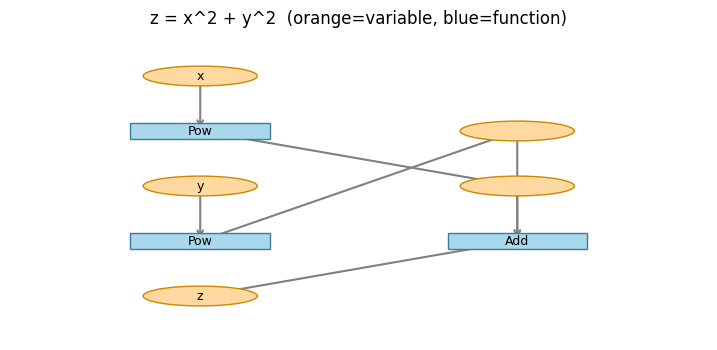

In [4]:
def draw_graph_matplotlib(output, title="computation graph"):
    # creator を辿ってノードとエッジを収集し、matplotlib で描画する簡易版
    # (Graphviz の代替。その場で図を確認するための実装)
    nodes = {}   # id -> (種類, ラベル, 世代)
    edges = []   # (from_id, to_id)

    funcs = []
    seen = set()
    def add_func(f):
        if f is not None and id(f) not in seen:
            funcs.append(f); seen.add(id(f))

    # 出力変数を登録
    out_gen = 0
    nodes[id(output)] = ('var', output.name or 'out', 0)
    add_func(output.creator)

    while funcs:
        f = funcs.pop()
        fgen = f.generation
        nodes[id(f)] = ('func', type(f).__name__, fgen)
        for y in f.outputs:
            edges.append((id(f), id(y())))
        for x in f.inputs:
            label = x.name if x.name else ''
            nodes[id(x)] = ('var', label, x.generation)
            edges.append((id(x), id(f)))
            if x.creator is not None:
                add_func(x.creator)

    # 世代ごとに x 座標を割り当て (世代 = 横位置)
    from collections import defaultdict
    by_gen = defaultdict(list)
    for nid, (kind, label, gen) in nodes.items():
        by_gen[gen].append(nid)
    pos = {}
    for gen, ids in by_gen.items():
        for i, nid in enumerate(ids):
            pos[nid] = (gen, i - (len(ids) - 1) / 2.0)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.axis('off')
    # エッジ
    for a, b in edges:
        xa, ya = pos[a]; xb, yb = pos[b]
        ax.annotate('', xy=(xb, yb), xytext=(xa, ya),
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
    # ノード
    for nid, (kind, label, gen) in nodes.items():
        px, py = pos[nid]
        if kind == 'var':
            ax.add_patch(plt.Circle((px, py), 0.18, color='#ffd9a0', ec='#cc8800', zorder=3))
        else:
            ax.add_patch(plt.Rectangle((px-0.22, py-0.15), 0.44, 0.3,
                                       color='#a8d8ea', ec='#3a7ca5', zorder=3))
        ax.text(px, py, label, ha='center', va='center', fontsize=9, zorder=4)
    xs = [p[0] for p in pos.values()]; ys = [p[1] for p in pos.values()]
    ax.set_xlim(min(xs)-0.6, max(xs)+0.6)
    ax.set_ylim(min(ys)-0.8, max(ys)+0.8)
    ax.set_title(title)
    plt.show()

# z = x^2 + y^2 のグラフを描画
x = Variable(np.array(1.0), name='x')
y = Variable(np.array(1.0), name='y')
z = x ** 2 + y ** 2
z.name = 'z'
draw_graph_matplotlib(z, title="z = x^2 + y^2  (orange=variable, blue=function)")


オレンジの丸が変数、水色の四角が関数 (`Pow` が2つ、`Add` が 1 つ) である。左から右へ順伝播が流れる様子が見える。これで、複雑な計算グラフも目で確認できる道具が揃った。  

> ステップ 25・26 のまとめ
>
> - Graphviz と DOT 言語で計算グラフを描画できる。
>
> - DeZero の `creator`/`inputs`/`outputs` を辿って DOT 文字列を自動生成 (`get_dot_graph`)。
>
> - この可視化は、後の高階微分 (複雑なグラフ) の助けになる。
>

---
# ステップ 27：テイラー展開の微分

可視化の準備ができたので、実際に使ってみる。`sin` 関数 を DeZero で実装し、さらに テイラー展開 を使って `sin` を近似的に計算し、その微分まで求る。  

## 27.1 sin 関数の実装

三角関数 $y = \sin(x)$ の微分は $\dfrac{dy}{dx} = \cos(x)$ であるから、DeZero で `Sin` クラスを実装するには、`forward` に `np.sin`、`backward` に「上流の微分 × $\cos(x)$」を書けばいい。  


In [5]:
class Sin(Function):
    def forward(self, x):
        y = np.sin(x)
        return y
    def backward(self, gy):
        x = self.inputs[0].data
        gx = gy * np.cos(x)   # sin の微分は cos。それに上流の微分 gy を掛ける
        return gx

def sin(x):
    return Sin()(x)

# 動作確認: y = sin(x) を x = π/4 で微分。 dy/dx = cos(π/4) = 1/√2 ≒ 0.707
x = Variable(np.array(np.pi / 4))
y = sin(x)
y.backward()
print("y      =", y.data,   "  (sin(π/4) ≒ 0.707)")
print("x.grad =", x.grad,   "  (cos(π/4) ≒ 0.707)")


y      = 0.7071067811865475   (sin(π/4) ≒ 0.707)
x.grad = 0.7071067811865476   (cos(π/4) ≒ 0.707)


## 27.2 テイラー展開の理論

テイラー展開とは、複雑な関数を多項式 (べき乗の足し算) で近似する方法。ある点 $a$ のまわりで、関数 $f(x)$ は次のように表せる。  

$$ f(x) = f(a) + f'(a)(x-a) + \frac{f''(a)}{2!}(x-a)^2 + \frac{f'''(a)}{3!}(x-a)^3 + \cdots $$

式の解釈：点 $a$ での「値」「傾き (1 階微分)」「曲がり具合 (2 階微分)」… を次々に足していくことで、元の関数に近づける。項を増やすほど近似が良くなる。  

特に $a = 0$ のまわりの展開をマクローリン展開と呼ぶ。$\sin(x)$ のマクローリン展開はきれいな形になる。  

$$ \sin(x) = \frac{x}{1!} - \frac{x^3}{3!} + \frac{x^5}{5!} - \frac{x^7}{7!} + \cdots = \sum_{i=0}^{\infty} \frac{(-1)^i}{(2i+1)!} x^{2i+1} $$

- 奇数乗の項だけが現れる ($x, x^3, x^5, \ldots$)。
- 符号が $+,-,+,-$ と交互に変わる ($(-1)^i$)。
- 分母は階乗 $(2i+1)!$ ($1!, 3!, 5!, \ldots$)。$i!$ は $1\times2\times\cdots\times i$。

この和を有限個で打ち切れば $\sin$ の近似計算になる。DeZero の演算子 (`+`, `**`, `/`) だけで書けるので、その微分も自動で求まる。  


## 27.3 テイラー展開の実装

`my_sin(x, threshold)` を実装する。各項 $t = \dfrac{(-1)^i}{(2i+1)!}x^{2i+1}$ を順に足していき、項の大きさが `threshold` より小さくなったら打ち切る (それ以上足しても近似はほぼ変わらないため)。  

> `math.factorial(n)` は $n!$ を計算する。`threshold` を小さくするほど多くの項を使い、近似精度が上がる。


In [6]:
import math

def my_sin(x, threshold=0.0001):
    y = 0
    for i in range(100000):
        # 第 i 項の係数：(-1)^i / (2i+1)!
        c = (-1) ** i / math.factorial(2 * i + 1)
        # 第 i 項：c * x^(2i+1)
        t = c * x ** (2 * i + 1)
        y = y + t     # 項を足し込む (DeZero の Variable なので計算グラフが作られる)
        # 項が十分小さくなったら打ち切り
        if abs(t.data) < threshold:
            break
    return y

# my_sin と本物の sin を比較 (x = π/4)
x = Variable(np.array(np.pi / 4))
y = my_sin(x)
y.backward()
print("my_sin(π/4)      =", y.data,  "  (本物の sin(π/4) ≒ 0.7071)")
print("my_sin の微分     =", x.grad,  "  (本物の cos(π/4) ≒ 0.7071)")


my_sin(π/4)      = 0.7071064695751781   (本物の sin(π/4) ≒ 0.7071)
my_sin の微分     = 0.7071032148228457   (本物の cos(π/4) ≒ 0.7071)


テイラー展開による近似 `my_sin` でも、本物の `sin` (値 0.7071) と微分 (`cos` = 0.7071) にほぼ一致した。今回、`my_sin` の中で `cos` を一切使っていないにもかかわらず微分が正しく求まっている。これは、DeZero が `+`, `**`, `/` といった基本演算の微分を自動で繋げてくれるおかげである。  

### 項数を増やすと近似がどう良くなるか (発展)

テイラー展開は「項を増やすほど近似が良くなる」と述べた。これを確認する。`threshold` を変える代わりに、使う項数を固定して `sin` を近似し、項数1, 2, 3, ... と増やしたときに、近似曲線が本物の `sin` にどう近づくかを確認する。  


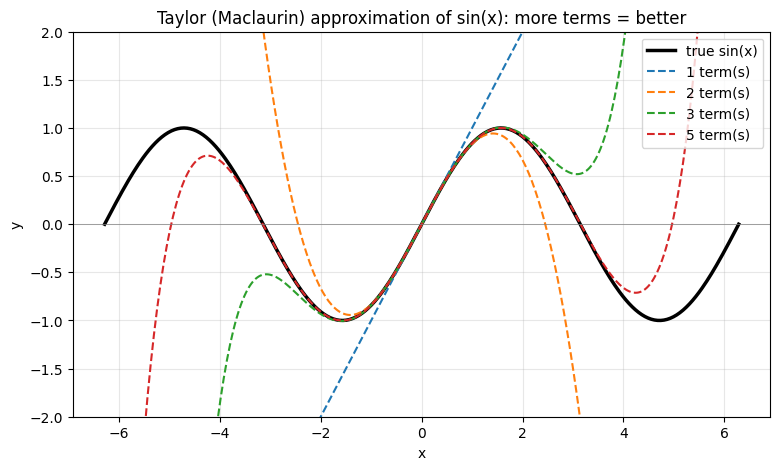

In [7]:
def my_sin_nterms(x, n_terms):
    # ちょうど n_terms 個の項で sin を近似する (numpy 版、描画用)
    y = np.zeros_like(x, dtype=float)
    for i in range(n_terms):
        c = (-1) ** i / math.factorial(2 * i + 1)
        y = y + c * x ** (2 * i + 1)
    return y

xs = np.linspace(-2 * np.pi, 2 * np.pi, 400)
true_sin = np.sin(xs)

plt.figure(figsize=(9, 5))
plt.plot(xs, true_sin, 'k-', lw=2.5, label='true sin(x)')
for n in [1, 2, 3, 5]:
    approx = my_sin_nterms(xs, n)
    plt.plot(xs, approx, '--', label=f'{n} term(s)')
plt.ylim(-2, 2)
plt.axhline(0, color='gray', lw=0.5)
plt.xlabel('x'); plt.ylabel('y')
plt.title('Taylor (Maclaurin) approximation of sin(x): more terms = better')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

項数 1 ($x$ だけ) では原点付近しか合わないが、項数を 5 まで増やすとかなり広い範囲で本物の `sin` に重なる。テイラー展開の「項を足すほど近似が良くなる」性質を確認した。  

> ステップ 27 のまとめ
>
> - `Sin` を実装 (`backward` は `cos`)。DeZero で三角関数も微分できる。
>
> - テイラー (マクローリン) 展開で `sin` を多項式近似。基本演算だけで書ける。
>
> - `cos` を使わずとも、自動微分により `my_sin` の微分が正しく求まる。
>
> - 項を増やすほど近似が改善することを可視化で確認。


---
# ステップ 28：関数の最適化

DeZero で微分が自動で求まるということは、それを使って関数の最小値を探す (最適化する) ことができる。ここでは有名なローゼンブロック関数を題材に、勾配降下法で最小値を探す。

## 28.1 ローゼンブロック関数

ローゼンブロック関数は、最適化アルゴリズムのベンチマークによく使われる関数である。  

$$ y = 100\,(x_1 - x_0^2)^2 + (1 - x_0)^2 $$

この関数は、細長く湾曲した谷を持つのが特徴で、最小化が難しいことで知られている。最小値は $(x_0, x_1) = (1, 1)$ で、そのとき $y = 0$ である。  

まず DeZero で定義し、$(x_0, x_1) = (0, 2)$ での微分 (勾配) を求めてみる。  


In [8]:
def rosenbrock(x0, x1):
    # ローゼンブロック関数：y = 100*(x1 - x0^2)^2 + (1 - x0)^2
    y = 100 * (x1 - x0 ** 2) ** 2 + (1 - x0) ** 2
    return y

x0 = Variable(np.array(0.0))
x1 = Variable(np.array(2.0))
y = rosenbrock(x0, x1)
y.backward()
# x0, x1 それぞれに関する偏微分 (勾配) が求まる
print("x0.grad =", x0.grad)
print("x1.grad =", x1.grad)


x0.grad = -2.0
x1.grad = 400.0


`x0.grad`, `x1.grad` が求まった。これは、点 $(0, 2)$ において「$y$ を最も増やす方向」を表すベクトル (勾配) である。  

## 28.3 勾配降下法

勾配降下法 (gradient descent) は、この勾配を使って最小値を探す最も基本的な方法である。アイデアはシンプルで、「勾配と逆向き (＝ 関数が減る向き) に少しずつ進む」ことを繰り返す。  

$$ x \leftarrow x - \eta\,\frac{\partial y}{\partial x} $$

- $\eta$ (イータ) は学習率。1 歩の大きさを決める小さな正の数。
- 勾配 $\frac{\partial y}{\partial x}$ の逆向き (マイナス) に進むのがポイント。

これをローゼンブロック関数に適用する。各ステップで `cleargrad()` を呼んで勾配をリセットするのを忘れないようにする (第 2 ステージで学んだ、勾配が加算される問題への対処)。


In [9]:
x0 = Variable(np.array(0.0))
x1 = Variable(np.array(2.0))
lr = 0.001        # 学習率 (小さめ。大きすぎると発散する)
iters = 1000      # 繰り返し回数

path = [(float(x0.data), float(x1.data))]   # 軌跡を記録 (可視化用)

for i in range(iters):
    y = rosenbrock(x0, x1)

    x0.cleargrad()    # 勾配をリセット (前回の勾配が残らないように)
    x1.cleargrad()
    y.backward()      # 勾配を計算

    # 勾配降下法の更新：勾配の逆向きに lr だけ進む
    x0.data -= lr * x0.grad
    x1.data -= lr * x1.grad
    path.append((float(x0.data), float(x1.data)))

print(f"最終位置：(x0, x1) = ({x0.data:.4f}, {x1.data:.4f})")
print(" (真の最小値は (1, 1)。1000 回では途中までしか進まない) ")


最終位置：(x0, x1) = (0.6837, 0.4660)
 (真の最小値は (1, 1)。1000 回では途中までしか進まない) 


1000 回の反復では、まだ最小値 $(1,1)$ に到達しきれていない。これはローゼンブロック関数の谷が細長く湾曲しているため、勾配降下法は谷底をジグザグ・ゆっくりとしか進めないためである。これを可視化して確認する。  

### 勾配降下法の軌跡を等高線上に描く (発展)

最適化の「軌跡」を等高線図に重ねて描く。勾配降下法が、細長い谷をどのように進んでいくか (ジグザグしながらゆっくり進む様子) を確認できる。  


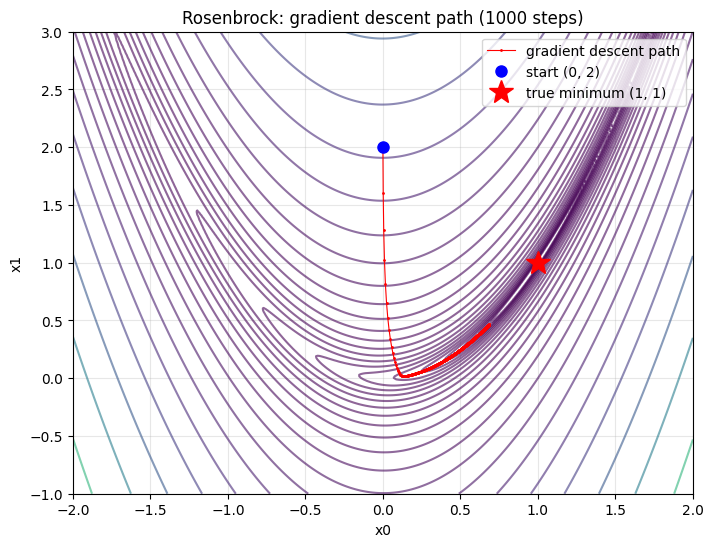

In [10]:
# ローゼンブロック関数の等高線と、勾配降下法の軌跡を描く
def rosenbrock_np(x0, x1):
    return 100 * (x1 - x0**2)**2 + (1 - x0)**2

r0 = np.linspace(-2, 2, 300)
r1 = np.linspace(-1, 3, 300)
X0, X1 = np.meshgrid(r0, r1)
Z = rosenbrock_np(X0, X1)

path_arr = np.array(path)

plt.figure(figsize=(8, 6))
# 対数スケールの等高線 (値の範囲が広いため)
levels = np.logspace(-1, 3.5, 25)
plt.contour(X0, X1, Z, levels=levels, cmap='viridis', alpha=0.6)
# 軌跡
plt.plot(path_arr[:, 0], path_arr[:, 1], 'r.-', markersize=2, lw=0.8, label='gradient descent path')
plt.plot(0, 2, 'bo', markersize=8, label='start (0, 2)')
plt.plot(1, 1, 'r*', markersize=18, label='true minimum (1, 1)')
plt.xlabel('x0'); plt.ylabel('x1')
plt.title('Rosenbrock: gradient descent path (1000 steps)')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

軌跡を見ると、勾配降下法は細長い谷にいったん降りたあと、谷底に沿ってゆっくりジグザグと進んでいる。1000 回でも最小値 $(1,1)$ にたどり着けていない。  

なぜ遅いのか？：

勾配降下法は「その場の傾き (1 階微分)」しか見ていないため、谷のカーブを先読みできず、遠回りしてしまう。そのような欠点を改良した手法が次に取り上げるニュートン法になる。

> ステップ 28 のまとめ
>
> - DeZero の自動微分で勾配を求め、勾配降下法で関数を最小化できる。
>
> - 更新式は $x \leftarrow x - \eta\,\frac{\partial y}{\partial x}$ (勾配の逆向きに進む)。
>
> - ローゼンブロック関数の細長い谷では、1 階微分だけの勾配降下法は遅い。


---
# ステップ 29：ニュートン法を用いた最適化 (手計算)

勾配降下法の弱点を克服する強力な手法がニュートン法である。重要な点は 2 階微分を使うこと。ここに「高階微分が欲しい」という第 3 ステージの動機がある。  

## 29.1 ニュートン法の理論

勾配降下法は、関数を 1 次関数 (直線) で近似して 1 歩進む方法とも言える。一方ニュートン法は、関数を 2 次関数 (放物線) で近似する。放物線なら「谷の底」が一発で分かるので、そこへ直接移動できる。  

数学的には、関数 $f(x)$ を点 $x$ のまわりで 2 次までテイラー展開する。  

$$ f(x + \Delta x) \approx f(x) + f'(x)\,\Delta x + \frac{1}{2}f''(x)\,\Delta x^2 $$

この放物線が最小になる $\Delta x$ を求めると ($\Delta x$ で微分して 0 とおくと)、  

$$ f'(x) + f''(x)\,\Delta x = 0 \quad\Rightarrow\quad \Delta x = -\frac{f'(x)}{f''(x)} $$

したがって、ニュートン法の更新式は次のようになる。  

$$ x \leftarrow x - \frac{f'(x)}{f''(x)} $$

勾配降下法との違い：勾配降下法の学習率 $\eta$ の代わりに $\dfrac{1}{f''(x)}$ が入っている。つまり 2 階微分 $f''(x)$ が「最適な歩幅」を自動で決めてくれる。これにより、ずっと速く最小値に到達できる。  

## 29.2 実装 (手計算の 2 階微分)

例として $y = x^4 - 2x^2$ を最小化する。この関数の微分を手計算で求める。  

$$ f(x) = x^4 - 2x^2 $$
$$ f'(x) = 4x^3 - 4x $$
$$ f''(x) = 12x^2 - 4 $$

今の DeZero は 1 階微分しか自動で求められないので、ここでは $f''(x)$ を手計算した式をコードに直接書く (`gx2` 関数)。ニュートン法を適用してみる。  


In [11]:
def f(x):
    y = x ** 4 - 2 * x ** 2
    return y

def gx2(x):
    # f''(x) = 12x^2 - 4 を手計算で用意 (今の DeZero では自動で出せない)
    return 12 * x ** 2 - 4

x = Variable(np.array(2.0))   # 初期値 x=2
iters = 10
newton_path = [float(x.data)]

for i in range(iters):
    y = f(x)
    x.cleargrad()
    y.backward()              # f'(x) は DeZero が自動で計算 (x.grad に入る)

    # ニュートン法の更新：x <- x - f'(x) / f''(x)
    x.data -= x.grad / gx2(x.data)
    newton_path.append(float(x.data))
    print(f"iter {i}: x = {x.data:.6f}")

iter 0: x = 1.454545
iter 1: x = 1.151047
iter 2: x = 1.025326
iter 3: x = 1.000908
iter 4: x = 1.000001
iter 5: x = 1.000000
iter 6: x = 1.000000
iter 7: x = 1.000000
iter 8: x = 1.000000
iter 9: x = 1.000000


わずか数回で $x = 1$ (最小値の 1 つ) に収束した。勾配降下法なら何十回もかかるところをニュートン法は 2 階微分のおかげで一気にたどり着ける。  

### ニュートン法 vs 勾配降下法の収束スピード比較 (発展)

同じ関数 $f(x)=x^4-2x^2$ を勾配降下法とニュートン法の両方で最小化し、収束の速さを比較する。ニュートン法が圧倒的に速いことを実際に確認する。  


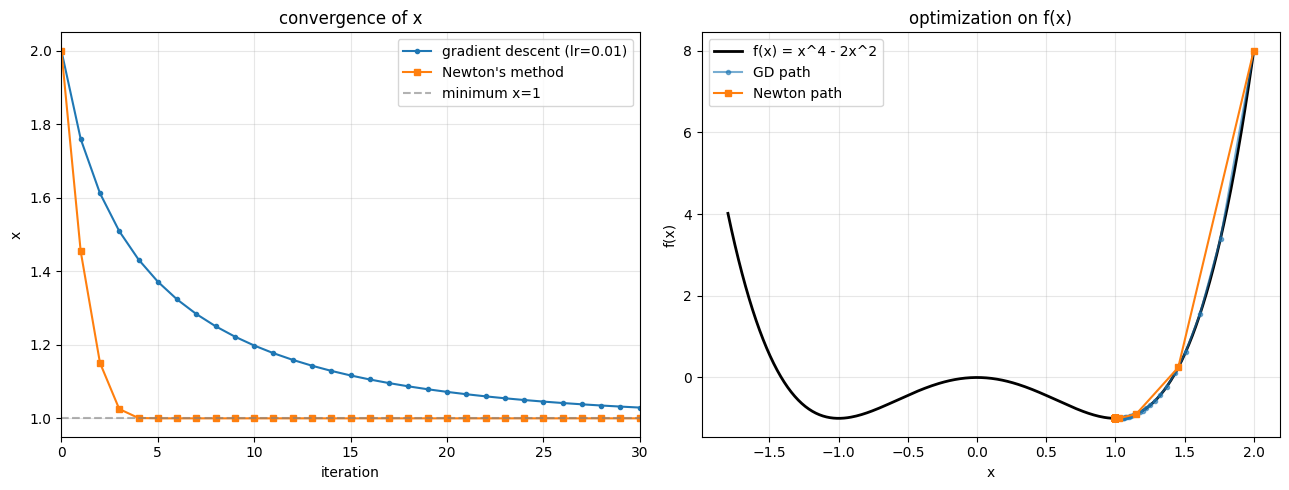

勾配降下法が x=1 に到達したステップ: None
ニュートン法が x=1 に到達したステップ: 5


In [12]:
def f_np(x):
    return x**4 - 2*x**2

# --- 勾配降下法 ---
x_gd = 2.0
lr = 0.01
gd_path = [x_gd]
for i in range(50):
    grad = 4 * x_gd**3 - 4 * x_gd     # f'(x)
    x_gd -= lr * grad
    gd_path.append(x_gd)

# --- ニュートン法 ---
x_nt = 2.0
nt_path = [x_nt]
for i in range(50):
    grad = 4 * x_nt**3 - 4 * x_nt     # f'(x)
    hess = 12 * x_nt**2 - 4           # f''(x)
    x_nt -= grad / hess
    nt_path.append(x_nt)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 左：x の値の推移
axes[0].plot(gd_path, 'o-', label='gradient descent (lr=0.01)', markersize=3)
axes[0].plot(nt_path, 's-', label="Newton's method", markersize=4)
axes[0].axhline(1, color='gray', ls='--', alpha=0.6, label='minimum x=1')
axes[0].set_xlabel('iteration'); axes[0].set_ylabel('x')
axes[0].set_title('convergence of x')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_xlim(0, 30)

# 右：関数の地形と、両手法の軌跡
xs = np.linspace(-1.8, 2.0, 300)
axes[1].plot(xs, f_np(xs), 'k-', lw=2, label='f(x) = x^4 - 2x^2')
axes[1].plot(gd_path, [f_np(x) for x in gd_path], 'o-', markersize=3, alpha=0.6, label='GD path')
axes[1].plot(nt_path, [f_np(x) for x in nt_path], 's-', markersize=4, label='Newton path')
axes[1].set_xlabel('x'); axes[1].set_ylabel('f(x)')
axes[1].set_title('optimization on f(x)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 何ステップで収束したか
def steps_to_converge(path, target=1.0, tol=1e-4):
    for i, v in enumerate(path):
        if abs(v - target) < tol:
            return i
    return None
print(f"勾配降下法が x=1 に到達したステップ: {steps_to_converge(gd_path)}")
print(f"ニュートン法が x=1 に到達したステップ: {steps_to_converge(nt_path)}")


左のグラフで、ニュートン法 (四角) が数ステップで $x=1$ に到達するのに対し、勾配降下法 (丸) はゆっくり近づく。2 階微分を使うことの効果は絶大であることを確認した。  

しかし、いぜんとして問題がある。ニュートン法には $f''(x)$ が必要だが、私たちは今回それを手計算した。関数が複雑になると、2 階微分を手で求めるのは大変で、間違いも起きやすい。「$f''(x)$ も自動で求めたい」―― これが高階微分を実装する強い動機である。  

> ステップ 29 のまとめ
>
> - ニュートン法は 2 階微分を使い、更新式 $x \leftarrow x - f'(x)/f''(x)$ で最小化。
>
> - 2 階微分が「最適な歩幅」を与えるため、勾配降下法より圧倒的に速い。
>
> - 今は $f''(x)$ を手計算するしかない → 自動で高階微分したいという動機が生まれる。


---
# ステップ 30：高階微分 (準備編)

いよいよ第 3 ステージの核心へ向かう準備である。ニュートン法のために　2　階微分を自動で求めたい。それを実現する前に、「今の DeZero がなぜ高階微分をできないのか」を、現状のコードで確認する。  

## 高階微分の考え方

2 階微分を自動で求めるには、どうすればいいか？  

> 逆伝播の計算自体を、もう一度 DeZero の計算グラフとして作る。そうすれば、その「微分を求めた計算」に対して、さらに `backward()` を呼ぶことで、微分の微分 (＝ 2 階微分) が求まる。  

普通の逆伝播は「1 階微分」を求める。もしその逆伝播の計算過程そのものが計算グラフになっていれば、その計算グラフに対してもう一度逆伝播でき、2 階微分が得られるはず。この「逆伝播で計算グラフを作る」という発想が次ステップ以降の鍵になる。  

## 確認作業：なぜ今はできないのか

現状の DeZero を確認する。ポイントは「逆伝播のとき、計算が `ndarray` で行われているか、それとも `Variable` で行われているか」になる。  

- もし逆伝播が `ndarray` (生の数値) で計算されているなら、そこに計算グラフは作られず、もう一度微分することはできない。  
- もし逆伝播が `Variable` で計算されているなら、そこにも計算グラフができ、さらに微分できる。  

現状の `backward` メソッドの中身を見てみる。  


In [13]:
# 現状の Variable.backward の「微分を取り出す核心部分」を抜き出して示す
backward_core = '''
def backward(self, retain_grad=False):
    ...
    while funcs:
        f = funcs.pop()
        gys = [output().grad for output in f.outputs]   # output().grad は ndarray
        gxs = f.backward(*gys)                            # ndarray 同士で計算
        ...
        for x, gx in zip(f.inputs, gxs):
            if x.grad is None:
                x.grad = gx        # ここで代入される gx も ndarray
            else:
                x.grad = x.grad + gx
'''
print(backward_core)



def backward(self, retain_grad=False):
    ...
    while funcs:
        f = funcs.pop()
        gys = [output().grad for output in f.outputs]   # output().grad は ndarray
        gxs = f.backward(*gys)                            # ndarray 同士で計算
        ...
        for x, gx in zip(f.inputs, gxs):
            if x.grad is None:
                x.grad = gx        # ここで代入される gx も ndarray
            else:
                x.grad = x.grad + gx



注目すべきは、逆伝播で微分を取り出している行  

```python
gys = [output().grad for output in f.outputs]   # ← output().grad は ndarray
gxs = f.backward(*gys)                           # ← ndarray 同士で計算
```

ここで `output().grad` は `ndarray` (生の数値) である。つまり、各関数の `backward` (たとえば `Sin.backward` の `gy * np.cos(x)`) は `ndarray` 同士の計算になっている。  

`ndarray` の計算には、DeZero の計算グラフは作られない。そのため、逆伝播で求めた微分 (`x.grad`) に対して、もう一度 `backward()` を呼んでも、2 階微分は得られない。  

これを実際に確かめてる。1 階微分 `x.grad` が `Variable` ではなく `ndarray` になっていることを確認する。  


In [15]:
# sin の微分を求め、x.grad の「型」を確認する
x = Variable(np.array(1.0))
y = sin(x)
y.backward()

print("x.grad      =", x.grad)
print("x.grad の型 =", type(x.grad).__module__ + "." + type(x.grad).__name__)


x.grad      = 0.5403023058681398
x.grad の型 = numpy.float64


x.grad は NumPy の値 (Variable ではない)  
※ 0 次元の計算では numpy.float64 というスカラ型になる。いずれにせよ NumPy 側の値で、Variable ではないため計算グラフを持たない  
数値としては正しいが (cos(1)≒0.5403)、これ自体には計算グラフが無い  
つまり、この grad に対してもう一度 backward() はできない → 2 階微分が取れない  

`x.grad` は `numpy.ndarray` だった。値は正しい ($\cos(1) \approx 0.5403$) のだが、これはただの数値であって `Variable` ではないため、計算グラフを持たない。したがって、この微分をさらに微分すること (2 階微分) はできない。  

## 解決の方針 (次ステップへの橋渡し)

問題の在り処がはっきりした。逆伝播の計算を `ndarray` ではなく `Variable` で行えばいい。そうすれば：  

1. 逆伝播の計算過程も計算グラフとして記録される。  
2. その計算グラフに対してもう一度 `backward()` を呼べる。  
3. 結果として 2 階微分 (さらには 3 階、4 階 … の高階微分) が自動で求まる。  

この改造には、`Variable` の `grad` を `ndarray` ではなく `Variable` で保持するように変え、各関数の `backward` も `Variable` で計算するように書き換える、という大きな改修が必要。それがステップ 31 (理論編)・32 (実装編) の内容になる。  

今回はその「なぜ必要か」「どこを直すべきか」を明確にできた。これが高階微分実装への第一歩になる。  

> ステップ 30 のまとめ
>
> - 高階微分の鍵は「逆伝播の計算自体を計算グラフにする」こと。
>
> - 現状は逆伝播が `ndarray` で計算されるため、微分に計算グラフが無く、再度微分できない。
>
> - `x.grad` が `ndarray` であることを確認 → これを `Variable` にするのが次の課題。
>
> - 次ステップ以降で、この改造により 2 階微分 (ニュートン法の自動化) を実現する。


---
# まとめ ― 第 3 ステージ前半 (ステップ25〜30)

この回では、高階微分の実装に向けた動機づけと準備、そして課題の特定を行った。  

1. ステップ 25・26 (可視化) Graphviz と DOT 言語で計算グラフを描画する (`get_dot_graph`) 準備をした。複雑なグラフを目視で確認できるように。
2. ステップ 27 (テイラー展開) `sin` を実装し、テイラー展開で近似。`cos` を使わずとも自動微分で `my_sin` の微分が求まることを確認。
3. ステップ 28 (最適化) 勾配降下法でローゼンブロック関数を最小化。1 階微分だけでは不十分なことを確認。
4. ステップ 29 (ニュートン法) 2 階微分を使うニュートン法が圧倒的に速いことを実演。ただし今は $f''$ を手計算する必要がある。
5. ステップ 30 (高階微分・準備編) 「逆伝播を計算グラフにすれば高階微分できる」という方針を提示。現状は `x.grad` が `ndarray` のため再微分できないことを確認。

### この回の内容
```
可視化の道具を作る (25-26)
   ↓
自動微分の威力を実感 (27：テイラー展開の微分)
   ↓
最適化に応用するが、勾配降下法は遅い (28)
   ↓
ニュートン法なら速いが、2 階微分が必要 (29)
   ↓
2 階微分を自動で求めたい → でも今の DeZero では無理 (30)
   ↓
【次ステージへ】逆伝播を計算グラフ化して高階微分を実現 (31〜)
```

### 次のステップ (ステップ 31 以降) へ
次は、いよいよ高階微分の実装である。`Variable` の `grad` を `Variable` にし、各関数の `backward` を `Variable` で計算するように改造する。これにより「微分の計算グラフ」が作られ、2 階微分・3 階微分 … が自動で求まるようになる。そして、ステップ 29 で手計算したニュートン法が、完全に自動化される。  